# Comparación con mecánica clasica

**Fecha:** 2026-04-03


In [1]:
!pip install -q -e ../../relatipy

In [6]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import relatipy.numeric as rn
import relatipy.visualization as rv

In [7]:
# Unidades geometrizadas
G = c = 1

# Parámetros del agujero negro
mass = 1
R_s = 2 * G * mass / c**2

# Parametros de la partícula
mass_particle = 1e-6
a = 100 * R_s
P = 2*np.pi*(a**3)**(1/2)

In [8]:
def get_orbit(times, **kwargs):
    sim = rb.Simulation()

    sim.add(m=mass)
    sim.add(m=mass_particle, **kwargs)

    # evolucionar el sistema
    coords = np.zeros((len(times), 3))
    velocities = np.zeros((len(times), 3))

    for i, t in enumerate(times):
        sim.integrate(t)
        coords[i, 0] = sim.particles[1].xyz[0]
        coords[i, 1] = sim.particles[1].xyz[1]
        coords[i, 2] = sim.particles[1].xyz[2]
        velocities[i, 0] = sim.particles[1].vxyz[0]
        velocities[i, 1] = sim.particles[1].vxyz[1]
        velocities[i, 2] = sim.particles[1].vxyz[2]

    coords = np.concatenate((times[:, np.newaxis], coords), axis=1)
    cartesian_coords = rn.coordinates.Cartesian(coords.T, velocities.T, mass)

    return cartesian_coords


In [10]:
times = np.linspace(0, 100*P, 500)

kerr = rn.metrics.Kerr(mass=mass, a=0.9)
rn_coords = rn.coordinates.OrbitalElements(t=0, a=a, inc=45, e=0, Omega=0, omega=0, f=0, mass=mass)

orbit_relativity = kerr.geodesic.get_path(rn_coords, times, integrator="Radau2")
orbit_relativity_mino = kerr.geodesic.get_path(rn_coords, times, integrator="Mino")
inclinations_relativity = orbit_relativity.convert_to("OrbitalElements", mass=1).inc

orbit = get_orbit(times, a=a, inc=45*np.pi/180)
inclinations = orbit.convert_to("OrbitalElements", mass=1).inc
inclinations_mino = orbit_relativity_mino.convert_to("OrbitalElements", mass=1).inc

In [11]:
from relatipy.visualization._3D.plot_black_hole import PlotKerr

plot = PlotKerr(kerr)
# plot.add_path(orbit, label="orbit")
plot.add_path(orbit_relativity, label="orbit_relativity", color="green")
plot.add_path(orbit_relativity_mino, label="orbit_relativity_mino", color="red")
plot.plot().show()

# # save ../figures/005-comparacion_con_mecanica_clasica/orbit.png as plotly html
# plot.plot().write_html("../figures/005-comparacion_con_mecanica_clasica/orbit.html")


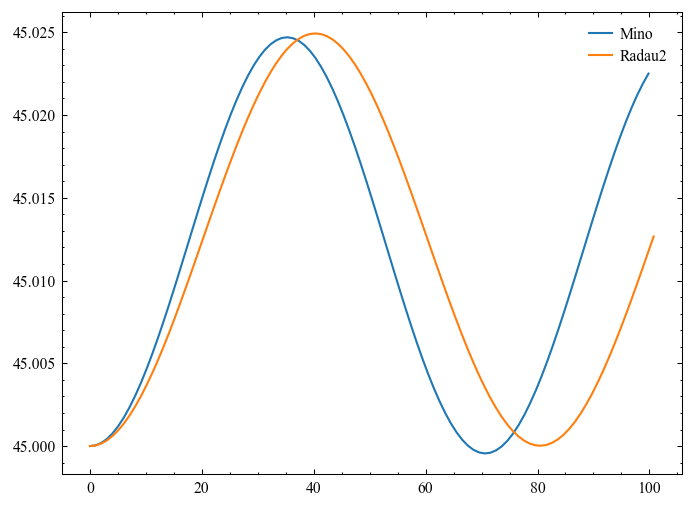

In [40]:
from relatipy.visualization._2D.sci import SciSubplot
workspace_ = SciSubplot()
fig, ax = workspace_.fig, workspace_.ax

ax.plot(orbit_relativity_mino[0, ::100]/P, inclinations_mino[::100], label="Mino"    )
ax.plot(orbit_relativity[0, ::100]/P, inclinations_relativity[::100], label="Radau2")
ax.legend()

In [23]:
import sys                                                                                                                                                   
sys.path.insert(0, "/Users/ldiaz/Documents/Documentos/otros/thesis_apply/notebooks")
         
from utils.periodogram import lombscargle_from_path

freqs_relativity, powers_relativity, amplitudes_relativity = lombscargle_from_path(orbit_relativity, "OrbitalElements", "inc")
freqs, powers, amplitudes = lombscargle_from_path(orbit, "OrbitalElements", "inc")

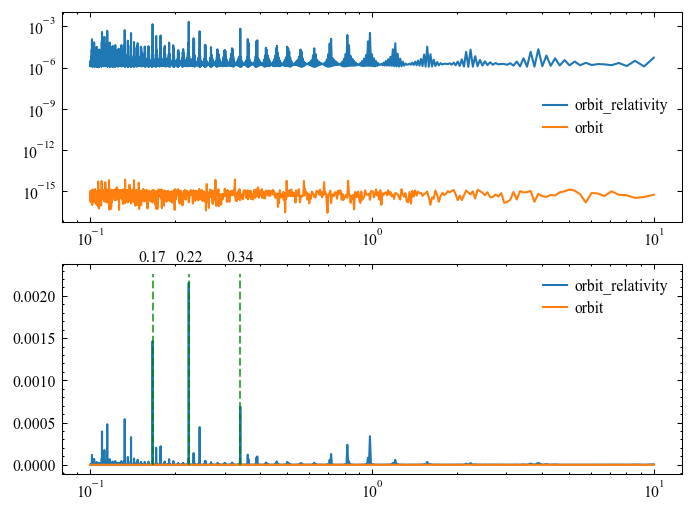

In [41]:
from relatipy.visualization._2D.sci import SciSubplot


workspace = SciSubplot(subplot=(2, 1))
fig, axs = workspace.fig, workspace.axs

axs[0].plot(1/freqs_relativity, amplitudes_relativity, label="orbit_relativity")
axs[0].plot(1/freqs, amplitudes, label="orbit")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].legend()

axs[1].plot(1/freqs_relativity, amplitudes_relativity, label="orbit_relativity")
axs[1].plot(1/freqs, amplitudes, label="orbit")
# Dibuja las 3 frecuencias dominantes (periodos) como líneas verticales que llegan arriba y el valor y de cada pico arriba de la línea en negro

ylim = axs[1].get_ylim()
y_top = ylim[1]

def get_top3_periods_and_amps(freqs, amplitudes):
    idx_top3 = np.argsort(amplitudes)[-3:][::-1]
    periods_top3 = 1 / freqs[idx_top3]
    amplitudes_top3 = amplitudes[idx_top3]
    return periods_top3, amplitudes_top3

periods_rel, amps_rel = get_top3_periods_and_amps(freqs_relativity, amplitudes_relativity)
periods_newt, amps_newt = get_top3_periods_and_amps(freqs, amplitudes)

y_offset = 0.038 * (y_top - ylim[0])  # desplazamiento vertical relativo para que el texto quede sobre la línea

for p, a in zip(periods_rel, amps_rel):
    axs[1].plot([p, p], [0, y_top], "g--", alpha=0.7)
    axs[1].text(p, y_top + y_offset, f"{p:.2}", color="k", fontsize=9, va='bottom', ha='center')

axs[1].set_xscale("log")

axs[1].legend()

plt.savefig("../figures/005-comparacion_con_mecanica_clasica/periods_and_amps_Radau2_vs_rebound.png")

In [25]:
import sys                                                                                                                                                   
sys.path.insert(0, "/Users/ldiaz/Documents/Documentos/otros/thesis_apply/notebooks")
         
from utils.periodogram import lombscargle_from_path

freqs_relativity_mino, powers_relativity_mino, amplitudes_relativity_mino = lombscargle_from_path(orbit_relativity_mino, "OrbitalElements", "inc")
freqs, powers, amplitudes = lombscargle_from_path(orbit, "OrbitalElements", "inc")

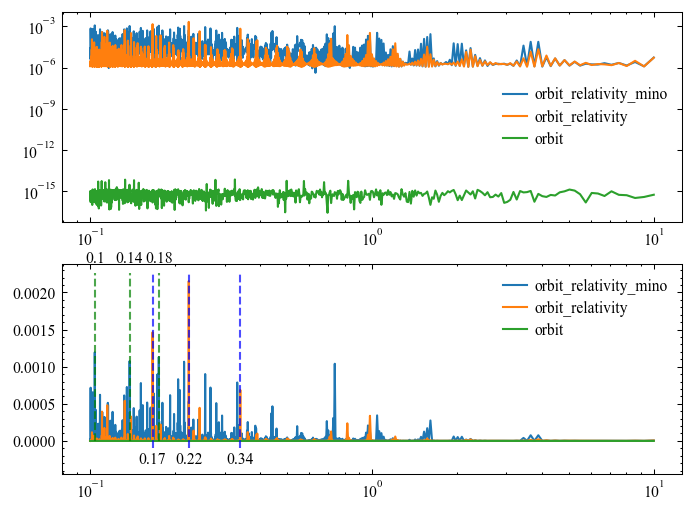

In [43]:
from relatipy.visualization._2D.sci import SciSubplot


workspace = SciSubplot(subplot=(2, 1))
fig, axs = workspace.fig, workspace.axs

axs[0].plot(1/freqs_relativity_mino, amplitudes_relativity_mino, label="orbit_relativity_mino")
axs[0].plot(1/freqs_relativity, amplitudes_relativity, label="orbit_relativity")
axs[0].plot(1/freqs, amplitudes, label="orbit")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].legend()

axs[1].plot(1/freqs_relativity_mino, amplitudes_relativity_mino, label="orbit_relativity_mino")
axs[1].plot(1/freqs_relativity, amplitudes_relativity, label="orbit_relativity")
axs[1].plot(1/freqs, amplitudes, label="orbit")
# Dibuja las 3 frecuencias dominantes (periodos) como líneas verticales que llegan arriba y el valor y de cada pico arriba de la línea en negro

ylim = axs[1].get_ylim()
y_top = ylim[1]

def get_top3_periods_and_amps(freqs, amplitudes):
    idx_top3 = np.argsort(amplitudes)[-3:][::-1]
    periods_top3 = 1 / freqs[idx_top3]
    amplitudes_top3 = amplitudes[idx_top3]
    return periods_top3, amplitudes_top3

# Calcular los top 3 para cada conjunto:
periods_mino, amps_mino = get_top3_periods_and_amps(freqs_relativity_mino, amplitudes_relativity_mino)
periods_rel, amps_rel = get_top3_periods_and_amps(freqs_relativity, amplitudes_relativity)
periods_newt, amps_newt = get_top3_periods_and_amps(freqs, amplitudes)

y_offset = 0.038 * (y_top - ylim[0])  # desplazamiento vertical relativo para que el texto quede sobre la línea

# Pintar los -- para mino (verde)
for p, a in zip(periods_mino, amps_mino):
    axs[1].plot([p, p], [0, y_top], "g--", alpha=0.7)
    axs[1].text(p, y_top + y_offset, f"{p:.2}", color="k", fontsize=9, va='bottom', ha='center')

# Pintar los -- para relativity (azul)
for p, a in zip(periods_rel, amps_rel):
    axs[1].plot([p, p], [-y_offset, y_top], "b--", alpha=0.7)
    axs[1].text(p, - y_offset*4, f"{p:.2}", color="k", fontsize=9, va='bottom', ha='center')

axs[1].set_xscale("log")
axs[1].set_ylim(-y_offset*5)
axs[1].legend()

plt.savefig("../figures/005-comparacion_con_mecanica_clasica/periods_and_amps_Radau2_vs_mino.png")